# **Importacion**


Luis Jose Gonzalez Montilla


In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 35.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b8bf02e52a86379e414855427bf5bbc505225d813abbd507a8f7fbba1d737340
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
from langdetect import detect


import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tag import pos_tag
from nltk.probability import FreqDist


In [ ]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("names")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger')
nltk.download('tagsets')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package

True

In [ ]:
STOPWORDS = nltk.corpus.stopwords.words("english")
NAMES = nltk.corpus.names.words()

# Analisis exploratorio de la data

In [ ]:
df = pd.read_csv('DisneylandReviews.csv', encoding='latin1')
#obtenido de https://www.kaggle.com/datasets/arushchillar/disneyland-reviews

In [ ]:
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
print(df.loc[0, 'Review_Text'])

If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the queues moved fairly well. 


<Axes: xlabel='Rating'>

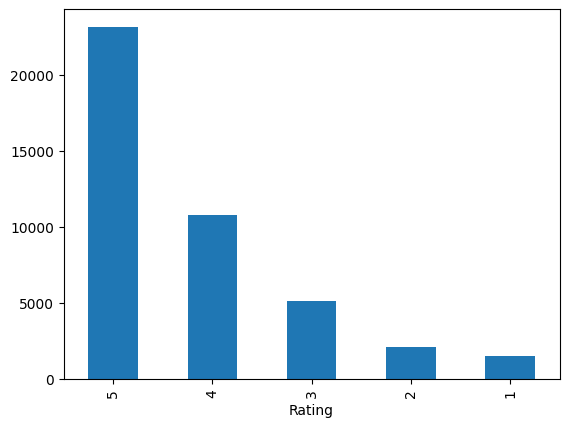

In [ ]:
df["Rating"].value_counts().plot(kind= "bar")

In [ ]:
df["sentiment"] = df["Rating"].apply(lambda x: "positive" if x > 3 else "negative")
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive
...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,positive
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,positive
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,positive
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,positive


<Axes: xlabel='sentiment'>

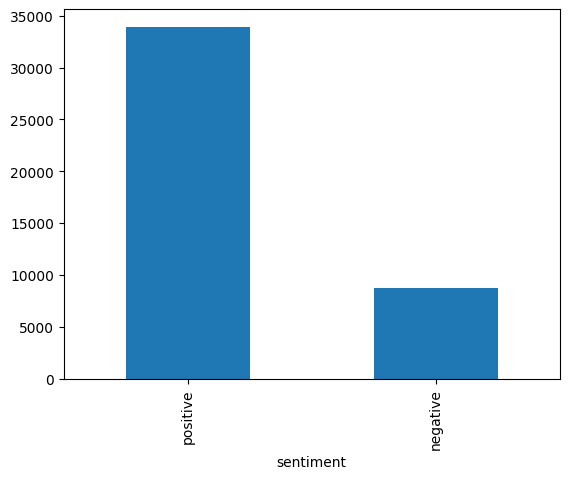

In [ ]:
df["sentiment"].value_counts().plot(kind= "bar")

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,33921
negative,8735


In [ ]:
df["sentiment"].value_counts(normalize= True)

,proportion
sentiment,
positive,0.795222
negative,0.204778


In [ ]:
min_size_of_target_class = df["sentiment"].value_counts().min()

df = pd.concat([
    df[df["sentiment"] == target].sample(min_size_of_target_class) for target in df["sentiment"].unique()
])
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive
...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative


In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,8735
negative,8735


In [ ]:
df["sentiment"].value_counts(normalize= True)

,proportion
sentiment,
positive,0.5
negative,0.5


In [ ]:
#Analisis de lenguaje
df["language"]= df["Review_Text"].apply(lambda x: detect(x))
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en
...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en


In [ ]:
df["language"].value_counts()

,count
language,
en,17467
fr,1
da,1
nl,1


In [ ]:
#Viendo filas a eliminar
df[df["language"] != "en"]

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
40916,134837144,5,2012-6,United Kingdom,"Excellent but very crowded long queue, Great p...",Disneyland_Paris,positive,fr
41345,127711668,5,2011-5,Ireland,A far better version of magic kingdom! Far bet...,Disneyland_Paris,positive,da
30690,565264346,3,2018-2,Netherlands,"Beautiful parks, but it has many outdated attr...",Disneyland_Paris,negative,nl


In [ ]:
#Nuevo dataframe completo en ingles
df = df[df["language"] == "en"]
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en
...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en


In [ ]:
df["prompt_length"] = df["Review_Text"].apply(lambda x: len(x))
df

/tmp/ipython-input-808850344.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["prompt_length"] = df["Review_Text"].apply(lambda x: len(x))


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en,212
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en,422
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en,797
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en,1289
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en,850
...,...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en,1612
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en,173
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en,2344
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en,1090


In [ ]:
# Revisa los outliers en términos de tamaño
df[df["prompt_length"] < 55]

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
26389,133309894,5,2012-6,United States,Can never get enough of Disney! Cars land was...,Disneyland_California,positive,en,53
27495,124231754,5,2011-12,United States,we had a great time just wish we had more days...,Disneyland_California,positive,en,52
29981,606997669,5,2018-8,France,ActiveX VT ERROR:,Disneyland_Paris,positive,en,18
9222,120886952,5,2011-10,Philippines,the best for kids and also the young at heart(...,Disneyland_HongKong,positive,en,52
27239,126069143,5,2012-3,United States,What's there to say? It's the happiest place o...,Disneyland_California,positive,en,54
41601,122872711,5,2012-1,United Kingdom,so many rides scary and not so kids loved the...,Disneyland_Paris,positive,en,51
28010,120590500,4,2011-10,United States,The only bad thing was Pirates was closed for ...,Disneyland_California,positive,en,53
27333,125483247,5,2012-2,Canada,Everything about Disney is awesome Disney ro...,Disneyland_California,positive,en,50
27182,126304731,5,missing,United States,"Lots of nostalgia. Clean, fun and safe but no...",Disneyland_California,positive,en,54
41466,125602048,3,2012-2,United Kingdom,Disappointed with size compared to florida cou...,Disneyland_Paris,negative,en,54


In [ ]:
df = df[df["prompt_length"] > 50]
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en,212
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en,422
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en,797
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en,1289
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en,850
...,...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en,1612
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en,173
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en,2344
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en,1090


# Preprocesamiento de texto

In [ ]:
def get_tokens(review, simplifier_func=None):
    tokens = word_tokenize(review)
    cleaned_tokens = []
    for token in tokens:
        if not token.isalpha(): continue
        if token in NAMES: continue
        token = token.lower()
        if token in STOPWORDS: continue
        if pos_tag([token])[0][1][:2] not in ["NN", "VB", "JJ", "RB"]: continue
        if simplifier_func: token = lemmatizer.lemmatize(token)
        cleaned_tokens.append(token)
    return cleaned_tokens

In [ ]:
df['tokens'] = df["Review_Text"].apply(lambda x: get_tokens(x))
df

/tmp/ipython-input-179938558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokens'] = df["Review_Text"].apply(lambda x: get_tokens(x))


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length,tokens
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en,212,"[absolutely, love, disneyland, stayed, propert..."
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en,422,"[went, whole, family, grand, time, food, outle..."
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en,797,"[hope, disney, christmas, magical, children, e..."
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en,1289,"[spent, days, nights, euro, disney, truly, mag..."
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en,850,"[god, ruddy, freezing, cold, wet, misrable, we..."
...,...,...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en,1612,"[guess, say, disneyland, little, overrated, si..."
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en,173,"[great, place, take, kids, worth, checking, ti..."
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en,2344,"[trip, disneyland, children, first, trip, year..."
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en,1090,"[family, got, bedroom, suite, floor, paradise,..."


# Comprension del vocabulario





In [ ]:
from collections import Counter

# Unir todas las reviews en una sola lista de palabras
todas_las_palabras = [palabra for lista_review in df['tokens'] for palabra in lista_review]

# Contar la frecuencia de cada palabra
vocabulario = Counter(todas_las_palabras)

# Mostrar las 10 palabras más comunes
print(vocabulario.most_common(10))


[('park', 18130), ('disney', 17308), ('rides', 15520), ('disneyland', 13882), ('time', 12189), ('day', 11827), ('get', 10208), ('go', 8923), ('ride', 8093), ('food', 6514)]


In [ ]:
df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,sentiment,language,prompt_length,tokens
22016,207612397,5,2013-6,United States,Absolutely love Disneyland! We stayed on prop...,Disneyland_California,positive,en,212,"[absolutely, love, disneyland, stayed, propert..."
8049,160233449,5,2012-6,Philippines,i went with my whole family. we had a grand ti...,Disneyland_HongKong,positive,en,422,"[went, whole, family, grand, time, food, outle..."
34832,333702398,5,2015-12,United Kingdom,You hope Disney at Christmas would be magical ...,Disneyland_Paris,positive,en,797,"[hope, disney, christmas, magical, children, e..."
39060,179028334,5,2013-9,United Kingdom,We have just spent four days and three nights ...,Disneyland_Paris,positive,en,1289,"[spent, days, nights, euro, disney, truly, mag..."
41528,124445510,5,2011-5,United Kingdom,"My god it was ruddy freezing, cold wet misrabl...",Disneyland_Paris,positive,en,850,"[god, ruddy, freezing, cold, wet, misrable, we..."
...,...,...,...,...,...,...,...,...,...,...
25961,138841448,3,2012-5,Canada,I guess you might say that Disneyland is a lit...,Disneyland_California,negative,en,1612,"[guess, say, disneyland, little, overrated, si..."
940,588388593,3,2018-6,Hong Kong,This is a great place to take your kids. If yo...,Disneyland_HongKong,negative,en,173,"[great, place, take, kids, worth, checking, ti..."
13474,458605828,3,2017-2,Canada,This was our 2nd trip to Disneyland with out t...,Disneyland_California,negative,en,2344,"[trip, disneyland, children, first, trip, year..."
18537,286930880,3,2015-7,United States,Our family of 6 got a 1 bedroom suite on the 1...,Disneyland_California,negative,en,1090,"[family, got, bedroom, suite, floor, paradise,..."


#Entrenamiento

In [ ]:
import os
import time
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.preprocessing import FunctionTransformer, label_binarize


# CONFIGURACIÓN Y UTILIDADES
CARPETA_ARTEFACTOS = "artifacts"
os.makedirs(CARPETA_ARTEFACTOS, exist_ok=True)


def convertir_a_denso(x):
    """Convierte una matriz dispersa en un array denso."""
    return x.toarray()


def obtener_vectorizadores():
    """Devuelve los tres vectorizadores a probar."""
    return {
        "Binario": CountVectorizer(binary=True, min_df=2),
        "Bow": CountVectorizer(binary=False, min_df=2),
        "TF-IDF": TfidfVectorizer(min_df=2)
    }


def obtener_modelos():
    """Define los modelos y sus parámetros para búsqueda."""
    return {
        "KNN": (
            KNeighborsClassifier(),
            {"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"]}
        ),
        "RandomForest": (
            RandomForestClassifier(random_state=42),
            {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 20]}
        ),
        "DecisionTree": (
            DecisionTreeClassifier(random_state=42),
            {"clf__max_depth": [None, 10, 20], "clf__min_samples_split": [2, 5]}
        ),
        "GaussianNB": (
            GaussianNB(),
            {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]}
        ),
        "MultinomialNB": (
            MultinomialNB(),
            {"clf__alpha": [0.5, 1.0]}
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=42),
            {"clf__n_estimators": [50, 100], "clf__learning_rate": [0.5, 1.0]}
        ),
    }


def calcular_metricas(y_real, y_pred, y_proba=None, etiquetas=None):
    """Calcula métricas de evaluación, incluyendo ROC-AUC si aplica."""
    acc = accuracy_score(y_real, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_real, y_pred, average="weighted", zero_division=0
    )
    try:
        if y_proba is not None and etiquetas is not None:
            y_bin = label_binarize(y_real, classes=etiquetas)
            roc_auc = roc_auc_score(y_bin, y_proba, average="weighted", multi_class="ovr")
        else:
            roc_auc = np.nan
    except Exception:
        roc_auc = np.nan
    return acc, precision, recall, f1, roc_auc


# FUNCIÓN PRINCIPAL
def entrenar_y_evaluar(df):

    # Convertir texto tokenizado en strings
    X = df["tokens"].apply(lambda x: " ".join(x)).astype(str)
    y = df["Rating"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    vectorizadores = obtener_vectorizadores()
    modelos = obtener_modelos()

    registros = []

    for nombre_vec, vec in vectorizadores.items():
        for nombre_mod, (modelo, parametros) in modelos.items():
            print(f"\nEntrenando: Vectorizador={nombre_vec} | Modelo={nombre_mod}")

            # Crear pipeline según tipo de modelo
            if nombre_mod == "GaussianNB":
                pipeline = Pipeline([
                    ("vect", vec),
                    ("a_denso", FunctionTransformer(convertir_a_denso, accept_sparse=True)),
                    ("clf", modelo)
                ])
            else:
                pipeline = Pipeline([
                    ("vect", vec),
                    ("clf", modelo)
                ])

            # Tiempo de entrenamiento
            inicio_entrenamiento = time.time()
            grid = GridSearchCV(pipeline, param_grid=parametros, cv=3, n_jobs=-1, verbose=0)
            grid.fit(X_train, y_train)
            tiempo_entrenamiento = time.time() - inicio_entrenamiento

            mejor_modelo = grid.best_estimator_

            # Tiempo de inferencia
            inicio_inferencia = time.time()
            y_pred = mejor_modelo.predict(X_test)
            tiempo_inferencia = (time.time() - inicio_inferencia) / len(X_test)

            # Probabilidades (si aplica)
            try:
                y_proba = mejor_modelo.predict_proba(X_test)
            except Exception:
                y_proba = None

            etiquetas = np.unique(y)
            acc, prec, rec, f1, roc_auc = calcular_metricas(y_test, y_pred, y_proba, etiquetas)

            # Observaciones automáticas según desempeño
            if acc >= 0.7:
                observacion = "Desempeño alto"
            elif acc < 0.4:
                observacion = "Desempeño bajo"
            else:
                observacion = "Desempeño medio"

            # Guardar modelo entrenado
            nombre_archivo = f"{nombre_mod}__{nombre_vec}.joblib"
            ruta_archivo = os.path.join(CARPETA_ARTEFACTOS, nombre_archivo)
            joblib.dump(mejor_modelo, ruta_archivo)

            # Registrar métricas
            registros.append({
                "Vectorizador": nombre_vec,
                "Modelo": nombre_mod,
                "Accuracy": round(acc, 4),
                "Precisión": round(prec, 4),
                "Recall": round(rec, 4),
                "F1": round(f1, 4),
                "ROC-AUC": round(roc_auc, 4) if not np.isnan(roc_auc) else None,
                "Tiempo Entrenamiento (s)": round(tiempo_entrenamiento, 3),
                "Tiempo Inferencia (s/pred)": round(tiempo_inferencia, 6),
                "Observaciones": observacion
            })

    # Guardar reporte
    df_metricas = pd.DataFrame(registros)
    salida_csv = os.path.join(CARPETA_ARTEFACTOS, "reporte_metricas.csv")
    df_metricas.to_csv(salida_csv, index=False)
    print(f"\nReporte guardado en: {salida_csv}")


    entrenar_y_evaluar(df)


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [ ]:
import os
import pandas as pd

# Ruta
RUTA_CSV = "/content/artifacts/metrics_report.csv"

def detectar_mejor_modelo(ruta_csv=RUTA_CSV):
    if not os.path.exists(ruta_csv):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta_csv}")

    # Leer el CSV
    df = pd.read_csv(ruta_csv)

    # Detectar nombres de columnas relevantes
    col_modelo = next((c for c in df.columns if c.lower().startswith("modelo")), None)
    col_vector = next((c for c in df.columns if c.lower().startswith("vector")), None)
    col_f1 = next((c for c in df.columns if "f1" in c.lower()), None)
    col_acc = next((c for c in df.columns if "acc" in c.lower()), None)
    col_obs = next((c for c in df.columns if "observ" in c.lower()), None)

    if not col_modelo or not col_vector:
        raise KeyError("No se encontraron columnas 'Modelo' y 'Vectorizador' en el archivo CSV.")

    # Ordenar por F1 o Accuracy
    if col_f1:
        df_sorted = df.sort_values(by=col_f1, ascending=False)
        metrica_usada = col_f1
    elif col_acc:
        df_sorted = df.sort_values(by=col_acc, ascending=False)
        metrica_usada = col_acc
    else:
        raise KeyError("No se encontraron columnas F1 ni Accuracy para evaluar el mejor modelo.")

    # Obtener la mejor fila
    mejor = df_sorted.iloc[0]

    print("MEJOR MODELO DETECTADO")

    print(f"Modelo:       {mejor[col_modelo]}")
    print(f"Vectorizador: {mejor[col_vector]}")
    print(f"Métrica usada: {metrica_usada}")
    print(f"Valor:         {mejor[metrica_usada]:.4f}")

    if col_obs:
        print(f"Observaciones: {mejor[col_obs]}")

    # Buscar la ruta del modelo si está en el CSV, o reconstruirla
    posibles_col_ruta = [c for c in df.columns if "ruta" in c.lower() or "artifact" in c.lower()]
    if posibles_col_ruta:
        ruta_modelo = mejor[posibles_col_ruta[0]]
    else:
        ruta_modelo = f"artifacts/{mejor[col_modelo]}__{mejor[col_vector]}.joblib"

    print(f"Ruta estimada: {ruta_modelo}")

    return mejor, ruta_modelo


if __name__ == "__main__":
    mejor_fila, ruta = detectar_mejor_modelo()


MEJOR MODELO DETECTADO
Modelo:       MultinomialNB
Vectorizador: BolsaPalabras
Métrica usada: F1
Valor:         0.5284
Observaciones: Desempeño medio
Ruta estimada: artifacts/MultinomialNB__BolsaPalabras.joblib


In [ ]:
import joblib
import pandas as pd
import random

MODEL_PATH = "/content/artifacts/MultinomialNB__bow.joblib"
DATA_PATH = "/content/DisneylandReviews.csv"
COLUMN_NAME = "Review_Text"
N_SAMPLES = 6

#CARGAR MODELO
print(f"Cargando modelo desde: {MODEL_PATH}")
model = joblib.load(MODEL_PATH)

#CARGAR DATA
print(f"Cargando dataset desde: {DATA_PATH}")
try:
    df = pd.read_csv(DATA_PATH, encoding="utf-8")
except UnicodeDecodeError:
    try:
        df = pd.read_csv(DATA_PATH, encoding="latin1")
    except UnicodeDecodeError:
        df = pd.read_csv(DATA_PATH, encoding="ISO-8859-1")

print("CSV cargado correctamente")

#VALIDAR COLUMNA
if COLUMN_NAME not in df.columns:
    raise ValueError(f"La columna '{COLUMN_NAME}' no existe. Columnas disponibles: {df.columns.tolist()}")

#LIMPIAR Y TOMAR MUESTRA
textos = df[COLUMN_NAME].dropna().astype(str)
samples = textos.sample(N_SAMPLES, random_state=random.randint(0, 9999))

#MAPEO DE CLASES
def interpretar_pred(pred):
    """
    1–2 -> negativo
    3–5 -> positivo
    """
    try:
        pred = int(pred)
        return "positivo" if pred >= 3 else "negativo"
    except:
        if str(pred).lower() in ["negativo", "negative"]:
            return "negativo"
        return "positivo"

#PREDICCIONES
print("\nVALIDANDO COMENTARIOS ALEATORIOS:\n")
for texto in samples:
    pred = model.predict([texto])[0]
    print(f"{texto}")
    print(f"→ Predicción: {interpretar_pred(pred)}\n")


Cargando modelo desde: /content/artifacts/MultinomialNB__bow.joblib
Cargando dataset desde: /content/DisneylandReviews.csv
CSV cargado correctamente

VALIDANDO COMENTARIOS ALEATORIOS:

My family and I drove down for Canada (3 times in the last 3 years) and we think its worth the over 20 hours of driving time each way! The key for us is to just enjoy every moment. We spend 5 days in the parks but we try to make sure we have a couple of days off in between to rest up (especially the kids). We make sure we take the time to do what each person wants, character interactions, shows, and of course rides! Have fun!!!
→ Predicción: positivo

We have just returned from a 4 day stay at DLP with our 4 children aged 5, 10 and 14. Not one to ever write reviews, I am totally appalled by the lack of so called 'magic' Disney Land Paris has to offer. There is a no smoking policy, however NO ONE adheres to it. You can be stood in a queue 250 people deep full of people smoking, happily puffing smoke into 